import the libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas_profiling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_curve, auc
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import sklearn.metrics as mt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/womens-ecommerce-clothing-reviews/Womens Clothing E-Commerce Reviews.csv


# Read dataset

In [2]:
df = pd.read_csv('/kaggle/input/womens-ecommerce-clothing-reviews/Womens Clothing E-Commerce Reviews.csv')

In [3]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
df.shape

(23486, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [6]:
df.describe()

,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


In [7]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

here the maximum null values are in the title and second most in the review text.

# group by the ratings as per the recommended id.

In [8]:
df.groupby(['Rating', 'Recommended IND'])['Recommended IND'].count()

Rating  Recommended IND
1       0                    826
        1                     16
2       0                   1471
        1                     94
3       0                   1682
        1                   1189
4       0                    168
        1                   4909
5       0                     25
        1                  13106
Name: Recommended IND, dtype: int64

we can drop some colums as they are not meaningfull for our data.

In [9]:
df1=df.drop(['Unnamed: 0','Division Name','Department Name',],axis=1)
df1.columns

Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Class Name'],
      dtype='object')

In [10]:
df1.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,Blouses


check the null values in the reviews columns and drop them from the column.

In [11]:
df1[df1['Review Text'].isnull()]

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Class Name
92,861,23,NaN,NaN,5,1,0,Knits
93,1081,31,NaN,NaN,5,1,0,Dresses
98,1133,50,NaN,NaN,5,1,0,Outerwear
135,861,35,NaN,NaN,4,1,0,Knits
142,1126,35,NaN,NaN,5,1,0,Outerwear
...,...,...,...,...,...,...,...,...
23258,862,35,NaN,NaN,4,1,0,Knits
23301,862,52,NaN,NaN,5,1,0,Knits
23303,823,46,NaN,NaN,5,1,0,Blouses
23470,1104,39,NaN,NaN,5,1,0,Dresses


dropping the null values for review text from the data

In [12]:
df1 = df1[~df1['Review Text'].isnull()]

In [13]:
df1.shape

(22641, 8)

In [14]:
df1.head(77)

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,Blouses
...,...,...,...,...,...,...,...,...
72,850,27,Beautiful design,I have a short torso and this works well for m...,5,1,4,Blouses
73,866,47,NaN,I love this top. it is loose and comfortable. ...,4,1,0,Knits
74,1081,59,NaN,I passed up this dress so many times in the st...,5,1,1,Dresses
75,845,48,Very very cute but a lot of fabric,I am so drawn to baby doll and boxy shirts so ...,5,1,5,Blouses


# Data Visualization

Let's find the how much clothes are recommendable in our data 

In [15]:
import plotly.offline as py
import plotly.graph_objs as go
x=df1['Recommended IND'].value_counts()
colors = ['#FEBFB3', '#E1396C']

trace=go.Pie(labels=x.index,values=x,textinfo="value",
            marker=dict(colors=colors, 
                           line=dict(color='#000000', width=2)))
layout=go.Layout(title="Cloths are Recommended or not",width=500,height=500)
fig=go.Figure(data=[trace],layout=layout)
py.iplot(fig, filename='pie_chart_subplots')

check the ratio of ratings in the data

In [16]:
import plotly.express as px
fig = px.histogram(df1, x=df1['Rating'], nbins=10)
fig.show()

check the count of the class name of clothes in the data

In [17]:

fig = px.histogram(df1, x = df1['Class Name'])
fig.show()

In [18]:
df1['review_len'] = df1['Review Text'].astype(str).apply(len)

In [19]:
px.histogram(df1, x = 'review_len')

In [20]:
df1['token_count'] = df1['Review Text'].apply(lambda x: len(str(x).split()))

In [21]:
px.histogram(df1, x = 'token_count')

In [22]:
!pip install TextBlob
from textblob import *

You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [23]:
df1['polarity'] = df1['Review Text'].map(lambda text: TextBlob(text).sentiment.polarity)
df1['polarity']

0        0.633333
1        0.339583
2        0.073675
3        0.550000
4        0.512891
           ...   
23481    0.552667
23482    0.091667
23483    0.414286
23484    0.322222
23485    0.413889
Name: polarity, Length: 22641, dtype: float64

In [24]:
fig = px.histogram(df1, x = df1['polarity'])
fig.show()

# Reviews with Positive Polarity

In [25]:
pop = df1.loc[df1.polarity == 1,['Review Text']].sample(3).values
for i in pop:
    print(i[0])

This is the perfect holiday dress. my best purchase of the season!
This is so flowing and perfect to hide any flaws.i adore it!
The details and colors are exquisite. stop hesitating and get this dress


# Reviews with Neutral Polarity

In [26]:
pop = df1.loc[df1.polarity == 0.5,['Review Text']].sample(3).values
for i in pop:
    print(i[0])

The lower part of dress bunches where buttons are, so the dress doesn't look flushed from top to bottom. i ended up returning it.
I love this ankle length pant. it is so comfortable wear it with a tunic or tee. i can wear this for 3 seasons!
Cute top for jeans or capri pants. love the sleeve length.


# Reviews with Negative Polarity

In [27]:
pop = df1.loc[df1.polarity < 0,['Review Text']].sample(3).values
for i in pop:
    print(i[0])

I ordered xs petite. which they are sold out of. but in case you are a different size i wanted to write a review. i'm 5 feet tall and 120 lbs. i am 34  d so busty. the petite did not overwhelm me. the pockets do open. you're supposed to cut the little threads out. ask a dry cleaner or an retailer stylist for help. i like that there is a little "stiffness" to the cape. it has holes for your arms. not a poncho. your lucky if they have your size!
I have literally dozens of deletta tops. just four things to know: very unique/attractive, run large/stretch out (size down), poor quality fabric, and usually low cut.
I didn't realize that the grey sleeves are attached (i assumed that was just an undershirt on the model). needless to say it looks cheap and poorly made. will be returning


([<matplotlib.patches.Wedge at 0x7fb01c38ad50>,
 [Text(1.0703951554160445, 0.25348414400483177, 'Positive'),
  Text(0.8761946463535268, 0.6650435637621179, 'Negative'),
  Text(-1.0058659275817003, -0.44523447275587896, 'Neutral')])

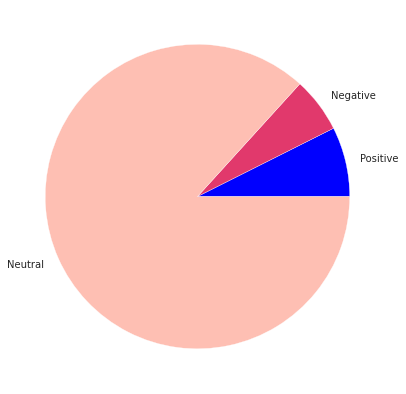

In [28]:
negative = (len(df1.loc[df1.polarity <0,['Review Text']].values)/len(df1))*100
positive = (len(df1.loc[df1.polarity >0.5,['Review Text']].values)/len(df1))*100
neutral  = len(df1.loc[df1.polarity >0 ,['Review Text']].values) - len(df1.loc[df1.polarity >0.5 ,['Review Text']].values)
neutral = neutral/len(df1)*100 
plt.figure(figsize =(10, 7)) 
plt.pie([positive,negative,neutral], labels = ['Positive','Negative','Neutral'],colors = [ 'blue','#E1396C','#FEBFB3'])

ratings with respect to the age of a customer

Text(0, 0.5, 'Age')

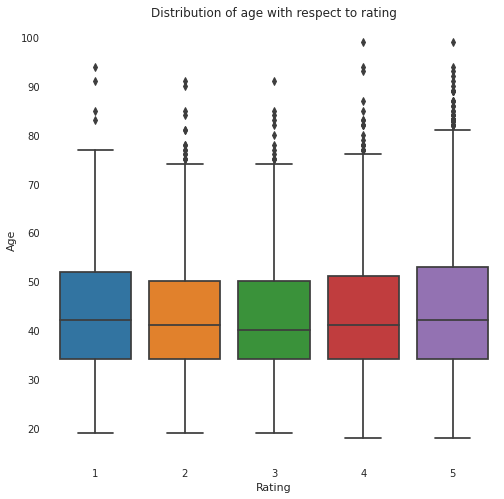

In [29]:
plt.figure(figsize=(8,8))
Age = df1['Age']
fx=sns.boxplot(x='Rating',y='Age',data=df1)
plt.title("Distribution of age with respect to rating")
plt.xlabel("Rating")
plt.ylabel("Age")

In [30]:
y = df1['Recommended IND']
X = df1.drop(columns = 'Recommended IND')

# Correlation

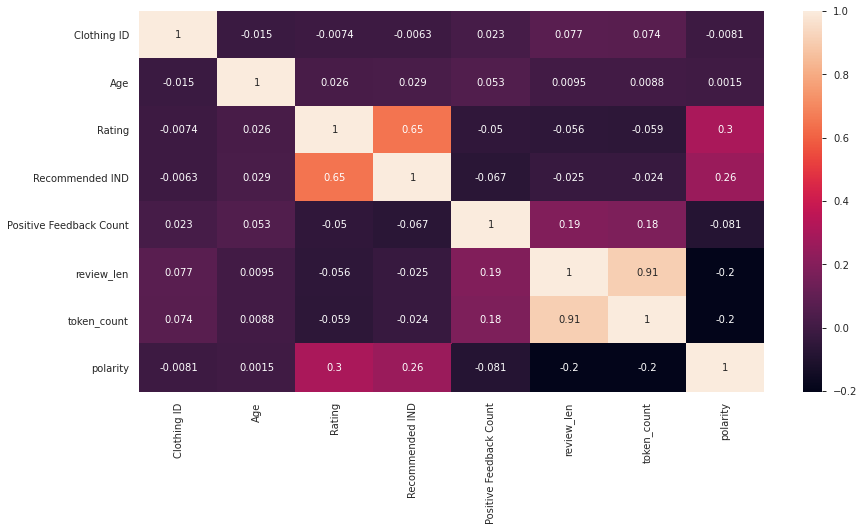

In [31]:
plt.figure(figsize=(14,7))
sns.heatmap(df1.corr(method='kendall'), annot=True )

# Handling Multi-Colinearity

In [32]:
set1 =set()
cor = df1.corr()
for i in cor.columns:
    for j in cor.columns:
        if cor[i][j]>0.8 and i!=j:
            set1.add(i)
print(set1)

{'token_count', 'review_len'}


In [33]:
X = X.drop(labels = ['token_count'],axis = 1)

In [34]:
X.corr()

,Clothing ID,Age,Rating,Positive Feedback Count,review_len,polarity
Clothing ID,1.000000,0.017688,-0.018454,0.044902,0.094115,-0.005498
Age,0.017688,1.000000,0.029962,0.040850,0.014931,0.006649
Rating,-0.018454,0.029962,1.000000,-0.060984,-0.056199,0.386303
Positive Feedback Count,0.044902,0.040850,-0.060984,1.000000,0.191195,-0.083379
review_len,0.094115,0.014931,-0.056199,0.191195,1.000000,-0.290693
polarity,-0.005498,0.006649,0.386303,-0.083379,-0.290693,1.000000


# Model Building

import some more libraries

In [35]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
stop=stopwords.words('english')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Let's see positive and negative words by using WordCloud.

Positive words are as follows


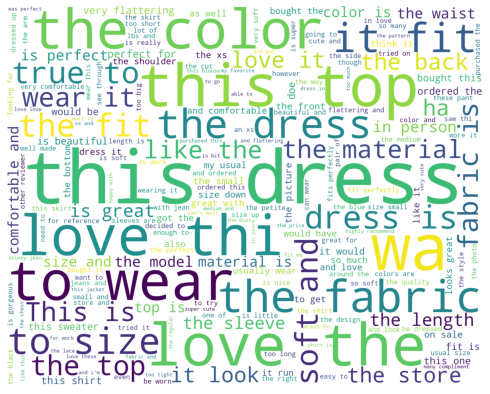

Negative words are as follows


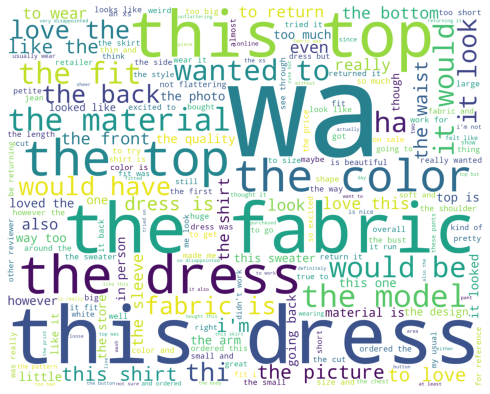

In [36]:
from wordcloud import WordCloud
positivedata = df1[ df1['Recommended IND'] == 1]
positivedata =positivedata['Review Text']
negdata = df1[df1['Recommended IND'] == 0]
negdata= negdata['Review Text']

def wordcloud_draw(df1, color = 'white'):
    words = ' '.join(df1)
    cleaned_word = " ".join([word for word in words.split()
                              if(word!='clothes' and word!='shop')
                            ])
    wordcloud = WordCloud(stopwords=stop,
                      background_color=color,
                      width=2500,
                      height=2000
                     ).generate(cleaned_word)
    plt.figure(1,figsize=(10, 7))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()
    
print("Positive words are as follows")
wordcloud_draw(positivedata,'white')
print("Negative words are as follows")
wordcloud_draw(negdata)

In [37]:
corpus =[]
X.index = np.arange(len(X))

In [38]:
for i in range(len(X)):
    review = re.sub('[^a-zA-z]',' ',X['Review Text'][i])
    review = review.lower()
    review = review.split()
    ps = PorterStemmer()
    review =[ps.stem(i) for i in review if not i in set(stopwords.words('english'))]
    review =' '.join(review)
    corpus.append(review)

# CountVectorizer 

In [39]:
from sklearn.feature_extraction.text import CountVectorizer as CV
cv  = CV(max_features = 3000,ngram_range=(1,1))
X_cv = cv.fit_transform(corpus).toarray()
y = y.values

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_cv, y, test_size = 0.20, random_state = 0)

# Bernoulli Naive Bayes

In [41]:
from sklearn.naive_bayes import BernoulliNB
classifier = BernoulliNB()
classifier.fit(X_train, y_train)

BernoulliNB()

In [42]:
y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print('accuracy:',acc)

accuracy: 0.8741444027379113


# Tf-Idf Vectorizer

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer as TV
tv  = TV(ngram_range =(1,1),max_features = 3000)
X_tv = tv.fit_transform(corpus).toarray()

# Mulinomial Naive Bayes

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X_tv, y, test_size = 0.20, random_state = 0)
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB()
classifier.fit(X_train, y_train)

MultinomialNB()

In [45]:
y_pred = classifier.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("accuracy:" , acc)

accuracy: 0.8370501214396114


# Random Forrest Model

In [46]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier()
classifier.fit(X_train,y_train)
preds=classifier.predict(X_test)
rf_accuracy=accuracy_score(preds,y_test)
print("Random Forest Model accuracy",rf_accuracy)

Random Forest Model accuracy 0.8487524839920513


# XGBoost Model

In [47]:
import xgboost as xgb
xgb=xgb.XGBClassifier()
xgb.fit(X_train,y_train)
preds2=xgb.predict(X_test)
xgb_accuracy=accuracy_score(preds2,y_test)
print("XGBoost Model accuracy",xgb_accuracy)

XGBoost Model accuracy 0.8708324133362774


# Logistic Regression Model

In [48]:
from sklearn.linear_model import LogisticRegressionCV
classifier=LogisticRegressionCV(cv=6,scoring='accuracy',random_state=0,n_jobs=-1,verbose=3,max_iter=500).fit(X_train,y_train)
y_pred1 = classifier.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   6 | elapsed:  4.3min remaining:  8.5min
[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:  6.6min finished


In [49]:
from sklearn import metrics
print("Logistic Regression Accuracy:",metrics.accuracy_score(y_test, y_pred1))

Logistic Regression Accuracy: 0.8836387723559285


# Deep Learning Model

# Creating a ANN structure

In [50]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
tokenizer = Tokenizer(num_words = 3000)
tokenizer.fit_on_texts(corpus)
sequences = tokenizer.texts_to_sequences(corpus)
padded = pad_sequences(sequences, padding='post')
word_index = tokenizer.word_index
count = 0
for i,j in word_index.items():
    if count == 11:
        break
    print(i,j)
    count = count+1

dress 1
fit 2
love 3
size 4
look 5
top 6
wear 7
like 8
color 9
great 10
would 11


In [51]:
embedding_dim = 64
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(3000, embedding_dim),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, None, 64)          192000    
_________________________________________________________________
global_average_pooling1d (Gl (None, 64)                0         
_________________________________________________________________
dense (Dense)                (None, 6)                 390       
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 7         
Total params: 192,397
Trainable params: 192,397
Non-trainable params: 0
_________________________________________________________________


In [52]:
num_epochs = 10

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.fit(padded,y,epochs= num_epochs,validation_split= 0.39)

Epoch 1/10
432/432 [==============================] - 2s 6ms/step - loss: 0.4473 - accuracy: 0.8202 - val_loss: 0.3629 - val_accuracy: 0.8217
Epoch 2/10
432/432 [==============================] - 2s 5ms/step - loss: 0.2877 - accuracy: 0.8718 - val_loss: 0.2711 - val_accuracy: 0.8852
Epoch 3/10
432/432 [==============================] - 2s 5ms/step - loss: 0.2337 - accuracy: 0.9014 - val_loss: 0.2647 - val_accuracy: 0.8858
Epoch 4/10
432/432 [==============================] - 2s 5ms/step - loss: 0.2149 - accuracy: 0.9113 - val_loss: 0.2685 - val_accuracy: 0.8855
Epoch 5/10
432/432 [==============================] - 2s 6ms/step - loss: 0.2023 - accuracy: 0.9185 - val_loss: 0.2690 - val_accuracy: 0.8866
Epoch 6/10
432/432 [==============================] - 2s 5ms/step - loss: 0.1927 - accuracy: 0.9222 - val_loss: 0.2734 - val_accuracy: 0.8873
Epoch 7/10
432/432 [==============================] - 2s 5ms/step - loss: 0.1846 - accuracy: 0.9267 - val_loss: 0.2832 - val_accuracy: 0.8851
Epoch 

# Visualising Model history

In [53]:
loss = model.history.history
loss = pd.DataFrame(loss)

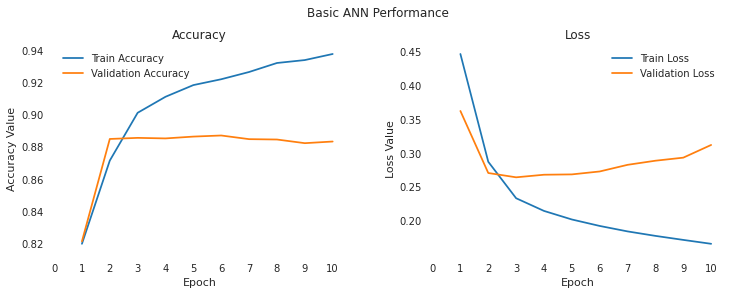

In [54]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
t = f.suptitle('Basic ANN Performance', fontsize=12)
f.subplots_adjust(top=0.85, wspace=0.3)

epoch_list = range(1,11)
ax1.plot(epoch_list, loss['accuracy'], label='Train Accuracy')
ax1.plot(epoch_list, loss['val_accuracy'], label='Validation Accuracy')
ax1.set_xticks(np.arange(0, 11, 1))
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")

ax2.plot(epoch_list, loss['loss'], label='Train Loss')
ax2.plot(epoch_list, loss['val_loss'], label='Validation Loss')
ax2.set_xticks(np.arange(0, 11, 1))
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
l2 = ax2.legend(loc="best")

# Checking the model on a random example

In [55]:
sample_string = "I hate this dress"
sample = tokenizer.texts_to_sequences(sample_string)
padded_sample = pad_sequences(sample, padding='post')
print("Padded sample", padded_sample.T)
print("Probabilty of a person recommending :",model.predict(padded_sample.T)[0][0]*100,"%")

Padded sample [[   0    0 1474    0    0 1115    0    0 1474    0    0    0    0 1309
  1115    0    0]]
Probabilty of a person recommending : 65.97405076026917 %


In [56]:
sample_string = "i love the fabric"
sample = tokenizer.texts_to_sequences(sample_string)
padded_sample = pad_sequences(sample, padding='post')
print("Padded sample", padded_sample.T)
print("Probabilty of a person recommending :",model.predict(padded_sample.T)[0][0]*100,"%")

Padded sample [[   0    0  280    0  411 1115    0    0 1474 1115    0  932    0  268
  1309    0  225]]
Probabilty of a person recommending : 99.96378421783447 %
